In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("data_ecommerce_customer_churn.csv")

In [5]:
df

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


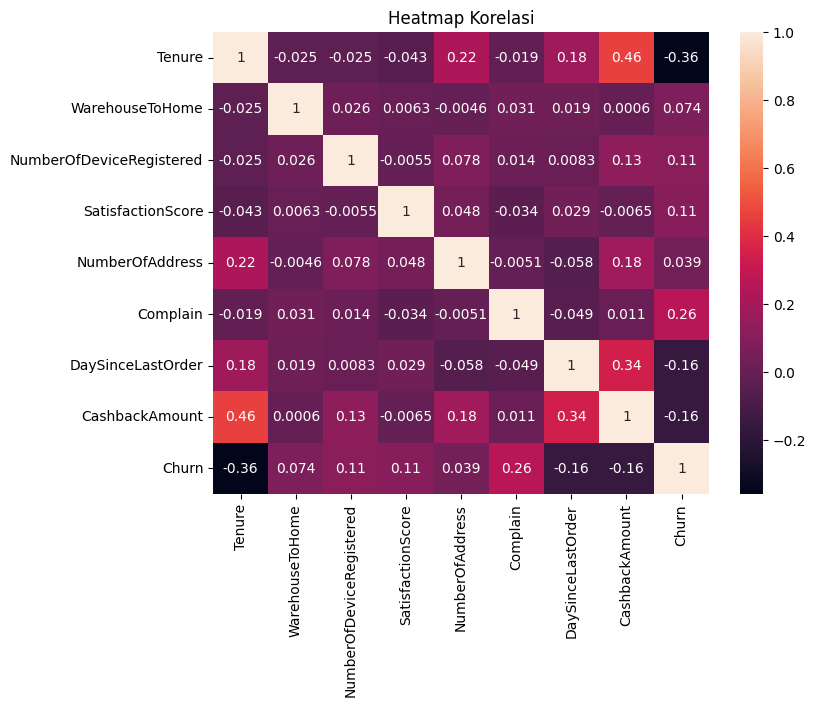

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Heatmap Korelasi")
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [25]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

# Get all numerical columns (features) in the DataFrame
numerical_features = df.select_dtypes(include=['number']).columns.drop('Churn')

# Impute missing values in all identified numerical feature columns
for col in numerical_features:
    if df[col].isnull().any(): # Only impute if there are actual NaNs in the column
        df[col] = imputer.fit_transform(df[[col]])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Inisialisasi model
nb = GaussianNB()

# Training model
nb.fit(X_train, y_train)

# Prediksi data test
y_pred_nb = nb.predict(X_test)

# Hitung akurasi
acc = accuracy_score(y_test, y_pred_nb)

# Tampilkan hasil
print("Akurasi Naive Bayes:", acc)

Akurasi Naive Bayes: 0.861850443599493


              precision    recall  f1-score   support

           0       0.91      0.93      0.92       660
           1       0.59      0.52      0.55       129

    accuracy                           0.86       789
   macro avg       0.75      0.72      0.73       789
weighted avg       0.86      0.86      0.86       789



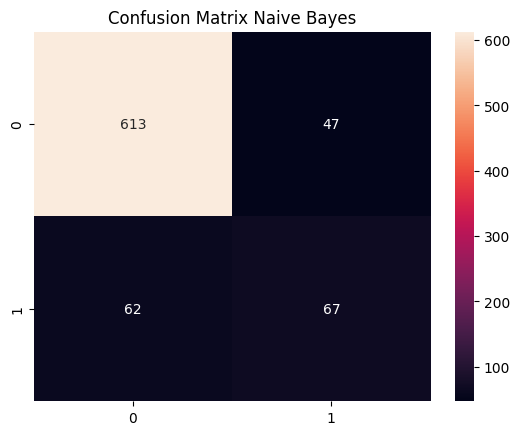

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Confusion Matrix Naive Bayes")
plt.show()

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

accuracy_score(y_test, y_pred_knn)

0.8948035487959443

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       660
           1       0.80      0.47      0.60       129

    accuracy                           0.89       789
   macro avg       0.85      0.73      0.77       789
weighted avg       0.89      0.89      0.88       789



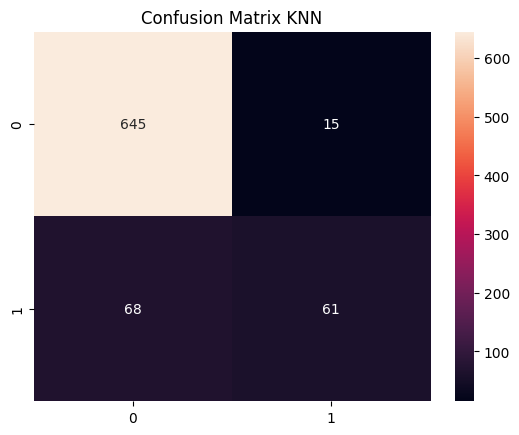

In [35]:
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Confusion Matrix KNN")
plt.show()

In [36]:
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_knn = accuracy_score(y_test, y_pred_knn)

hasil = pd.DataFrame({
    "Model":["Naive Bayes","KNN"],
    "Accuracy":[acc_nb, acc_knn]
})

hasil

,Model,Accuracy
0,Naive Bayes,0.861850
1,KNN,0.894804


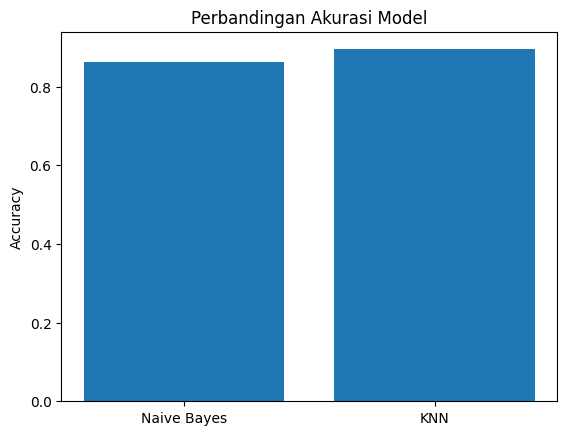

In [37]:
plt.bar(hasil["Model"], hasil["Accuracy"])
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy")
plt.show()